C:\Users\ricar\AppData\Local\Temp\ipykernel_15644\2905449324.py:9: DeprecationWarning:


Use of plotly.io.kaleido.scope.mathjax is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.mathjax instead.




Data loaded. Converted to MPH for US audience.


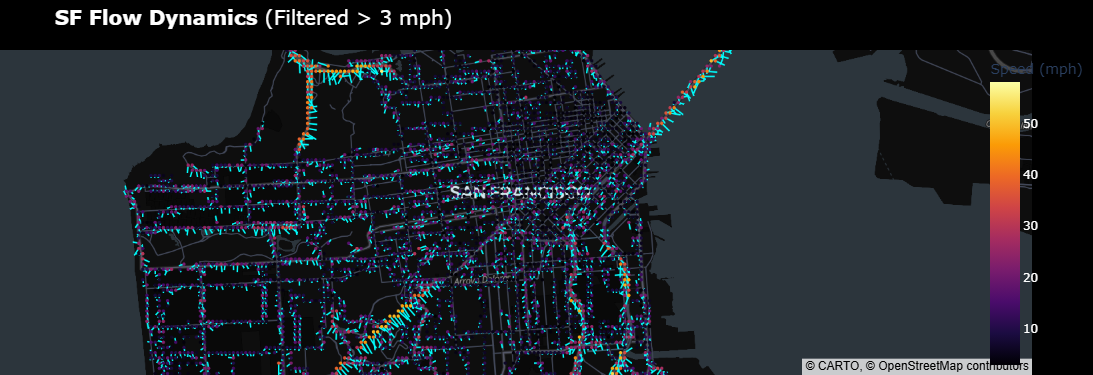

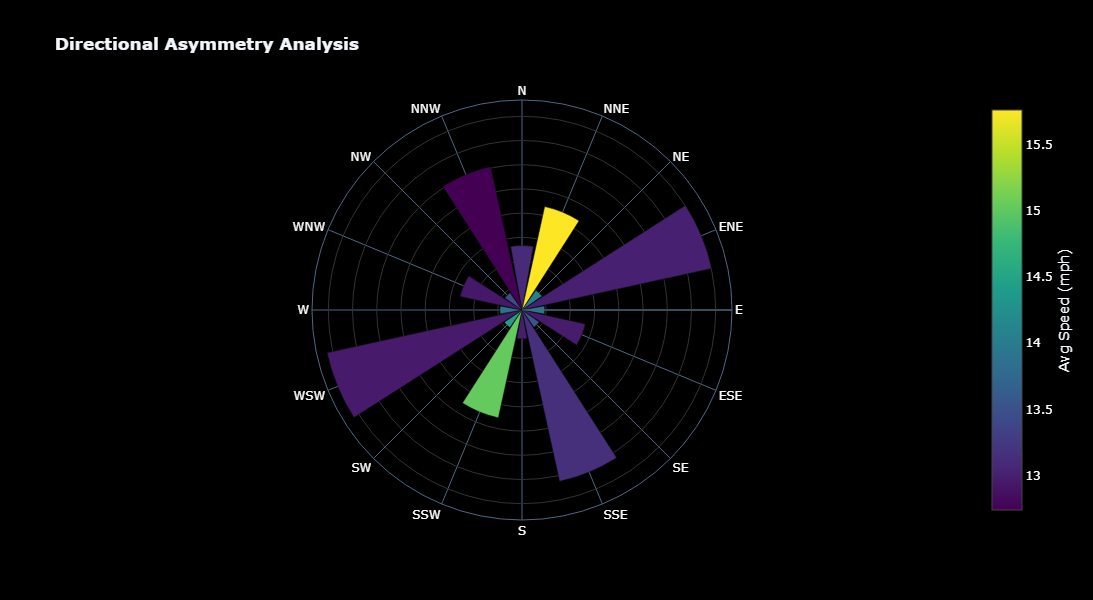

C:\Users\ricar\AppData\Local\Temp\ipykernel_15644\2905449324.py:184: DeprecationWarning:

*densitymapbox* is deprecated! Use *densitymap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



KaleidoError: Error 525: No valid mapbox style found, please set `mapbox.style` to one of:
carto-darkmatter, carto-positron, open-street-map, stamen-terrain, stamen-toner, stamen-watercolor, white-bg
or register a Mapbox access token to use a Mapbox-served style.

In [8]:
import pandas as pd
import numpy as np
import sqlite3
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# Configuración para asegurar que las imágenes estáticas se generen bien
pio.kaleido.scope.mathjax = None

# 1. CARGA DE DATOS
# ---------------------------------------------------------
conn = sqlite3.connect("traffic.db")
# Tu tabla original usa 'speed_kmh', confirmando que viene en métrico
traffic = pd.read_sql_query("SELECT * FROM SF_snapshots", conn)
conn.close()

# Procesamiento de fechas
traffic['timestamp_retrieved'] = pd.to_datetime(traffic['timestamp_retrieved'])
traffic['hour'] = traffic['timestamp_retrieved'].dt.hour

# --- CONVERSIÓN A FORMATO DE EE.UU. (MPH) ---
# Creamos la columna en Millas porque la pediste en formato US.
# Si no hacemos esto, los números no tendrán sentido para una audiencia de USA.
traffic['speed_mph'] = traffic['speed_kmh'] * 0.621371

# Creamos la copia de trabajo
df_vis = traffic.copy()

print("Data loaded. Converted to MPH for US audience.")


# 2. GRÁFICO DE FLUJO (FLOW DYNAMICS)
# ---------------------------------------------------------
# Redondeo para crear la cuadrícula
df_vis['lat_bin'] = df_vis['lat'].round(3)
df_vis['lon_bin'] = df_vis['lon'].round(3)

# Agrupamos usando la nueva columna en MPH
grid = df_vis.groupby(['lat_bin', 'lon_bin']).agg({
    'speed_mph': 'mean',
    'bearing': 'mean',
    'vehicle_id': 'count'
}).reset_index()

# Filtramos tráfico muy lento (< 3 mph para reducir ruido)
grid = grid[grid['speed_mph'] > 3]

# Cálculos vectoriales
grid['rads'] = np.radians(90 - grid['bearing'])
scale_factor = 0.00006  # Ajustado ligeramente para MPH

grid['delta_lon'] = np.cos(grid['rads']) * grid['speed_mph'] * scale_factor
grid['delta_lat'] = np.sin(grid['rads']) * grid['speed_mph'] * scale_factor

# Preparar líneas
start_lats = grid['lat_bin'].values
start_lons = grid['lon_bin'].values
end_lats = start_lats + grid['delta_lat'].values
end_lons = start_lons + grid['delta_lon'].values

empty = np.full(len(grid), None)
lats_lines = np.column_stack((start_lats, end_lats, empty)).flatten()
lons_lines = np.column_stack((start_lons, end_lons, empty)).flatten()

# Visualización
fig1 = go.Figure()

fig1.add_trace(go.Scattermap(
    lat=lats_lines, lon=lons_lines,
    mode='lines',
    line=dict(width=1.5, color='#00ffff'),
    hoverinfo='skip',
    name='Flow'
))

fig1.add_trace(go.Scattermap(
    lat=grid['lat_bin'], lon=grid['lon_bin'],
    mode='markers',
    marker=dict(
        size=4,
        color=grid['speed_mph'], # Usamos MPH
        colorscale='Inferno',
        showscale=True,
        colorbar=dict(title="Speed (mph)", x=0.95, tickfont=dict(color='white'))
    ),
    text=grid['speed_mph'].round(1).astype(str) + ' mph',
    hoverinfo='text',
    name='Speed'
))

fig1.update_layout(
    title=dict(text="<b>SF Flow Dynamics</b> (Filtered > 3 mph)", font=dict(color='white', size=20)),
    # IMPORTANTE: Usamos 'carto-darkmatter' para permitir la descarga gratuita sin token
    map=dict(style="carto-darkmatter", center=dict(lat=37.7749, lon=-122.4194), zoom=11.5),
    paper_bgcolor='black',
    margin={"r":0,"t":50,"l":0,"b":0},
    showlegend=False
)

# Descargar y mostrar
fig1.write_image("SF_Flow_Dynamics_MPH.png", width=1200, height=800, scale=2)
fig1.show()


# 3. ANÁLISIS DIRECCIONAL (POLAR CHART)
# ---------------------------------------------------------
df_polar = df_vis[df_vis['speed_mph'] > 1].copy()
bins = np.linspace(0, 360, 17)
labels = ["N", "NNE", "NE", "ENE", "E", "ESE", "SE", "SSE", "S", "SSW", "SW", "WSW", "W", "WNW", "NW", "NNW"]

df_polar['cardinal_direction'] = pd.cut(df_polar['bearing'], bins=bins, labels=labels, include_lowest=True)

polar_data = df_polar.groupby('cardinal_direction', observed=False).agg(
    frequency=('vehicle_id', 'count'),
    mean_speed=('speed_mph', 'mean')
).reset_index()

fig2 = go.Figure()
fig2.add_trace(go.Barpolar(
    r=polar_data['frequency'],
    theta=polar_data['cardinal_direction'],
    marker=dict(
        color=polar_data['mean_speed'],
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title='Avg Speed (mph)', title_side='right', tickfont=dict(color='white'))
    ),
    name='Direction'
))

fig2.update_layout(
    title="<b>Directional Asymmetry Analysis</b>",
    template='plotly_dark',
    paper_bgcolor='black',
    polar=dict(
        bgcolor='black',
        radialaxis=dict(visible=True, showticklabels=False, gridcolor='#333'),
        angularaxis=dict(tickfont=dict(color='white'), rotation=90, direction="clockwise")
    ),
    height=600
)

fig2.write_image("Directional_Analysis_MPH.png", width=1000, height=800, scale=2)
fig2.show()


# 4. MAPA DE RIESGO (SAFETY RISK MAP)
# ---------------------------------------------------------
# Cálculo de físicas (Aceleración)
df_telematics = df_vis.sort_values(['vehicle_id', 'timestamp_retrieved'])
df_telematics['dt'] = df_telematics.groupby('vehicle_id')['timestamp_retrieved'].diff().dt.total_seconds()
df_telematics['dv_mph'] = df_telematics.groupby('vehicle_id')['speed_mph'].diff()

# Filtrar intervalos válidos
df_telematics = df_telematics[(df_telematics['dt'] > 0) & (df_telematics['dt'] < 60)]

# Aceleración en MPH por segundo
df_telematics['accel_mphs'] = df_telematics['dv_mph'] / df_telematics['dt']

# Filtro de frenado brusco (ajustado para MPH)
# -5.6 mph/s es aprox -2.5 m/s^2 (tu umbral original)
hard_braking = df_telematics[df_telematics['accel_mphs'] < -5.6]
hard_braking = hard_braking[hard_braking['accel_mphs'] > -35] # Limpiar ruido

fig3 = go.Figure()

# Capa de eventos individuales
fig3.add_trace(go.Scattermap(
    lat=hard_braking['lat'], lon=hard_braking['lon'],
    mode='markers',
    marker=dict(
        size=8,
        color=hard_braking['accel_mphs'],
        colorscale='Reds_r',
        opacity=0.7,
        cmin=-15, cmax=-5.6
    ),
    text="Decel: " + hard_braking['accel_mphs'].round(1).astype(str) + " mph/s",
    name='Braking'
))

# Capa de densidad
fig3.add_trace(go.Densitymapbox(
    lat=hard_braking['lat'], lon=hard_braking['lon'],
    z=hard_braking['accel_mphs'].abs(),
    radius=15, colorscale="Hot", opacity=0.5,
    name='Risk Density'
))

fig3.update_layout(
    title="<b>Telematics Risk Map</b><br>Hard Braking (Decel > 5.6 mph/s)",
    # Nuevamente, carto-darkmatter para permitir descarga
    map=dict(style="carto-darkmatter", center=dict(lat=37.7749, lon=-122.4194), zoom=12),
    paper_bgcolor='black',
    font=dict(color='white'),
    margin={"r":0,"t":50,"l":0,"b":0},
    showlegend=False
)

fig3.write_image("Safety_Risk_Map_MPH.png", width=1200, height=800, scale=2)
fig3.show()